# **EXPLORATORY DATA ANALYSIS (EDA)**

#**1. Import Libraries & Load Data**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = "/content/drive/MyDrive/EDA_DataCo_SupplyChain/DataCoSupplyChainDatasetRefined.csv"
df = pd.read_csv(file_path)

#**2. Initial Data Inspection**

## **2.1 Dataset Shape**

In [ ]:
df.shape

(180519, 58)

## **2.2 Column Overview**

In [ ]:
df.columns

Index(['type', 'days_for_shipping_real', 'days_for_shipment_scheduled',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_email', 'customer_fname', 'customer_id',
       'customer_lname', 'customer_password', 'customer_segment',
       'customer_state', 'customer_street', 'customer_zipcode',
       'department_id', 'department_name', 'latitude_src', 'longitude_src',
       'market', 'order_city', 'order_country', 'order_customer_id',
       'order_date_dateorders', 'order_id', 'order_item_cardprod_id',
       'order_item_discount', 'order_item_discount_rate', 'order_item_id',
       'order_item_product_price', 'order_item_profit_ratio',
       'order_item_quantity', 'sales', 'order_item_total',
       'order_profit_per_order', 'order_region', 'order_state', 'order_status',
       'order_zipcode', 'product_card_id', 'product_category_id',
       'product_

## **2.3 Data Types**

In [ ]:
df.dtypes

,0
type,object
days_for_shipping_real,int64
days_for_shipment_scheduled,int64
benefit_per_order,float64
sales_per_customer,float64
delivery_status,object
late_delivery_risk,int64
category_id,int64
category_name,object
customer_city,object


#**3. Data Cleaning & Preprocessing**

##**3.1 Missing Values Analysis**

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
order_zipcode,155679
customer_lname,8
customer_zipcode,3
days_for_shipment_scheduled,0
sales_per_customer,0
benefit_per_order,0
late_delivery_risk,0
category_id,0
type,0
delivery_status,0


In [ ]:
df.drop(columns=['order_zipcode'], inplace=True)
df.drop(columns=['customer_lname'], inplace=True)
df.drop(columns=['customer_zipcode'], inplace=True)

##**3.2 Date Conversion**

In [ ]:
df['order_date_dateorder|s'] = pd.to_datetime(df['order_date_dateorders'], errors='coerce')
df['shipping_date_dateorders'] = pd.to_datetime(df['shipping_date_dateorders'], errors='coerce')

## **3.3 Feature Engineering (Important)**

### **Shipping Delay**

In [ ]:
df['shipping_delay_days'] = df['days_for_shipping_real'] - df['days_for_shipment_scheduled']

### **Late Delivery Flag**

In [ ]:
df['is_late_flag'] = np.where(df['shipping_delay_days'] > 0, 1, 0)

### **Kiểm tra giá trị âm**

In [ ]:
df[['sales', 'benefit_per_order', 'order_profit_per_order']].describe()

,sales,benefit_per_order,order_profit_per_order
count,180519.000000,180519.000000,180519.000000
mean,203.772096,21.974989,21.974989
std,132.273077,104.433526,104.433526
min,9.990000,-4274.979980,-4274.979980
25%,119.980003,7.000000,7.000000
50%,199.919998,31.520000,31.520000
75%,299.950012,64.800003,64.800003
max,1999.989990,911.799988,911.799988


In [ ]:
df.shape

(180519, 57)

In [ ]:
df.columns

Index(['type', 'days_for_shipping_real', 'days_for_shipment_scheduled',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_email', 'customer_fname', 'customer_id',
       'customer_password', 'customer_segment', 'customer_state',
       'customer_street', 'department_id', 'department_name', 'latitude_src',
       'longitude_src', 'market', 'order_city', 'order_country',
       'order_customer_id', 'order_date_dateorders', 'order_id',
       'order_item_cardprod_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'order_item_product_price',
       'order_item_profit_ratio', 'order_item_quantity', 'sales',
       'order_item_total', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'product_card_id', 'product_category_id',
       'product_image', 'product_name', 'product_price', 'product_status',
   

# **4. EDA – Exploratory Data Analysis**

## **4.1 Univariate Analysis**

### **4.1.1 Shipping Delay Distribution**

In [ ]:
df['shipping_delay_days'].describe()

,shipping_delay_days
count,180519.000000
mean,0.565807
std,1.490966
min,-2.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,4.000000


### **4.1.2 Late Delivery Ratio**

In [ ]:
df['is_late_flag'].value_counts(normalize=True)

,proportion
is_late_flag,
1,0.572793
0,0.427207


### **4.1.3 Profit Distribution**

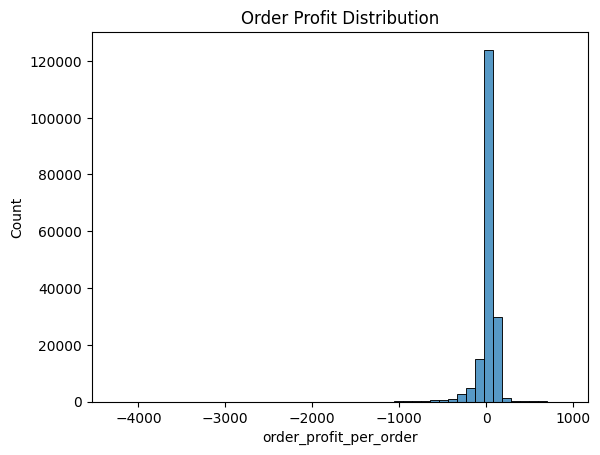

In [ ]:
sns.histplot(df['order_profit_per_order'], bins=50)
plt.title("Order Profit Distribution")
plt.show()

## **4.2 Bivariate Analysis**

### **4.2.1 Late Delivery vs Profit**

In [ ]:
df.groupby('is_late_flag')['order_profit_per_order'].mean()

,order_profit_per_order
is_late_flag,
0,22.496873
1,21.585751


### **4.2.2 Shipping Mode vs Delay**

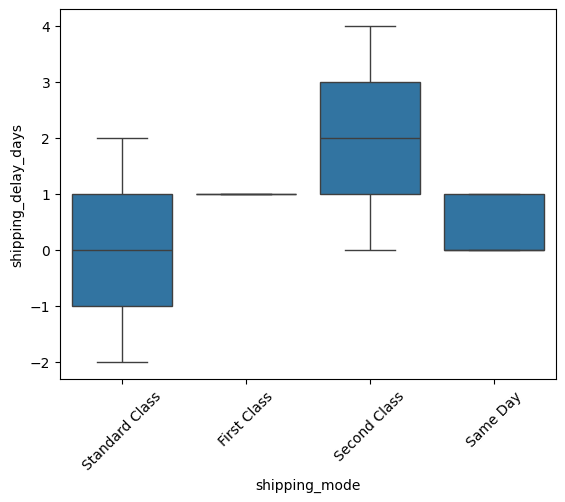

In [ ]:
sns.boxplot(
    x='shipping_mode',
    y='shipping_delay_days',
    data=df
)
plt.xticks(rotation=45)
plt.show()

## **4.3 Multivariate Analysis**

### **4.3.1 Shipping Mode × Late Flag × Profit**

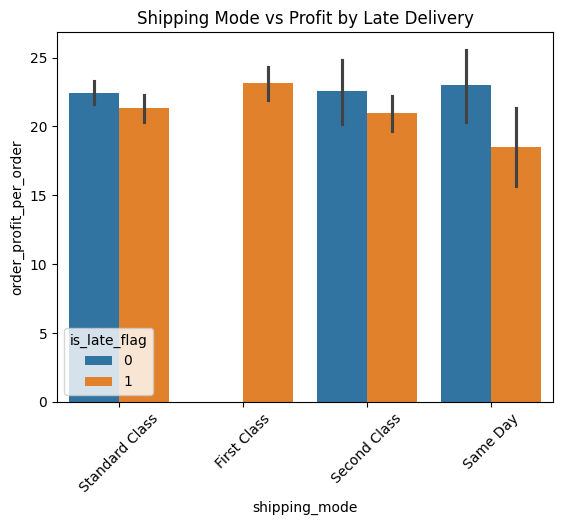

In [ ]:
sns.barplot(
    x='shipping_mode',
    y='order_profit_per_order',
    hue='is_late_flag',
    data=df
)
plt.xticks(rotation=45)
plt.title("Shipping Mode vs Profit by Late Delivery")
plt.show()